In [1]:
import notebook_setup
import matplotlib.pyplot as plt
import numpy as np
import json

from src.plot_style import set_plot_style

set_plot_style()

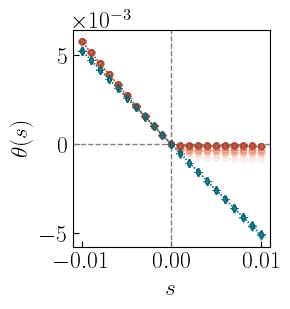

In [3]:
def cm_to_inch(cm):
    return cm / 2.54

with open("data/SCGF_data.json","r") as f:
    SCGF_data = json.load(f)

s_range = np.linspace(-0.01, 0.01, 21)
V_values = [5.875, 2.0]
num_sites_range = [4, 6, 8, 10, 20, 40, 60]

gradient_orange_1 = ["#FBE9E3","#F6CFC3","#F0B2A0","#EA937D","#E37259","#C85D47","#9F4736"]
gradient_orange_03 = [(251/255, 233/255, 227/255, 0.3),(246/255, 207/255, 195/255, 0.3),
                       (240/255, 178/255, 160/255, 0.3),(234/255, 147/255, 125/255, 0.3),
                       (227/255, 114/255, 89/255, 0.3),(200/255, 93/255, 71/255, 0.3),
                       (159/255, 71/255, 54/255, 0.3)]
gradient_teal_1 = ["#E4F3F6","#B8E0E7","#82C9D6","#4FB2C6","#2C9CB5","#1F7F95","#166370"]
gradient_teal_03 = [(228/255, 243/255, 246/255, 0.3),(184/255, 224/255, 231/255, 0.3),
                    (130/255, 201/255, 214/255, 0.3),(79/255, 178/255, 198/255, 0.3),
                    (44/255, 156/255, 181/255, 0.3),(31/255, 127/255, 149/255, 0.3),
                    (22/255, 99/255, 112/255, 0.3)]

panel_width_cm = 5.0
panel_height_cm = 5.5
margin_cm = 2.0

fig_width = cm_to_inch(panel_width_cm + 2 * margin_cm)
fig_height = cm_to_inch(panel_height_cm + 2 * margin_cm)

fig = plt.figure(figsize=(fig_width, fig_height))

left = margin_cm / (panel_width_cm + 2 * margin_cm)
bottom = margin_cm / (panel_height_cm + 2 * margin_cm)
width = panel_width_cm / (panel_width_cm + 2 * margin_cm)
height = panel_height_cm / (panel_height_cm + 2 * margin_cm)

ax = fig.add_axes([left, bottom, width, height])

ax.axhline(0, color='grey', linewidth=1, linestyle='--')
ax.axvline(0, color='grey', linewidth=1, linestyle='--')

for n, L in enumerate(num_sites_range):
    for V in V_values:
        key = f"SCGF_V_{V}_L_{L}_large" 
        large_values = SCGF_data[key]
        key = f"SCGF_V_{V}_L_{L}_small" 
        small_values = SCGF_data[key]
        colors, darker_colors = (gradient_orange_03, gradient_orange_1) if V==5.875 else (gradient_teal_03, gradient_teal_1)
        marker = 'o' if V==5.875 else 'd'
        errors = [abs(lv - sv) for lv, sv in zip(large_values, small_values)]
        ax.errorbar(s_range, large_values, yerr=errors, linestyle='None', capsize=3, elinewidth=1,
                    c=darker_colors[n], zorder=1, capthick=0.5, lw=0.5)
        ax.plot(s_range, large_values, marker=marker, markersize=4,
                markerfacecolor=colors[n], markeredgecolor=darker_colors[n],
                lw=0.8, ls=':', color=darker_colors[n])
ax.set_xlabel(r"$s$", fontsize=17)
ax.set_ylabel(r"$\theta(s)$", fontsize=17)
ax.set_xticks([-0.01, 0.0, 0.01])
ax.tick_params(axis='x', labelsize=17)
ax.tick_params(axis='y', labelsize=17)

from matplotlib.ticker import ScalarFormatter
sf = ScalarFormatter(useMathText=True)
sf.set_powerlimits((0,0))
ax.yaxis.set_major_formatter(sf)
ax.yaxis.offsetText.set_fontsize(17)

plt.savefig('figures/svg/fig3_a.svg', dpi=300, transparent=True)
plt.savefig('figures/pdf/fig3_a.pdf', dpi=300, transparent=True)
plt.show()
